In [398]:
import math
import random
from graphviz import Digraph
import matplotlib.pyplot as plt

%matplotlib inline

In [42]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [304]:
class Value:
    def __init__(self, data, prev=(), op=None):
        self.data = data
        self.grad = 0.0
        self._prev = set(prev)
        self._op = op
        self._backward = lambda:None

    def __repr__(self):
        return f"Value({self.data})"

    def __add__(self, other):
        other = Value(other) if not isinstance(other, Value) else other
        out = self.data + other.data
        val = Value(out, (self, other), "+")

        def _backward():
            self.grad += val.grad * 1.0
            other.grad += val.grad * 1.0

        val._backward = _backward
        return val

    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + other*-1

    def __rsub__(self, other):
        return -1*self + other

    def __mul__(self, other):
        other = Value(other) if not isinstance(other, Value) else other
        out = self.data * other.data
        val = Value(out, (self, other), "*")

        def _backward():
            self.grad += val.grad * other.data
            other.grad += val.grad * self.data

        val._backward = _backward
        return val

    def __rmul__(self, other):
        return self * other

    def __pow__(self, exponent):
        if not isinstance(exponent, (int, float)):
            raise TypeError("exponent must be either an int or float")
        out = self.data**exponent
        val = Value(out, (self,), "**")

        def _backward():
            self.grad += val.grad * (exponent * self.data**(exponent-1))

        val._backward = _backward
        return val

    def __truediv__(self, other):
        return self * other**(-1)

    def __rtruediv__(self, other):
        return other * self**(-1)

    def exp(self):
        # e^x
        out = math.exp(self.data)
        val = Value(out, (self,), "exp")

        def _backward():
            self.grad += val.grad * out

        val._backward = _backward
        return val
    
    def tanh(self):
        # e^2x-1/e^2x+1
        out = math.tanh(self.data)
        val = Value(out, (self,), "tanh")

        def _backward():
            self.grad += val.grad * (1 - out**2)
        
        val._backward = _backward
        return val

    def relu(self):
        # max(0, x)
        out = max(0, self.data)
        val = Value(out, (self,), "relu")

        def _backward():
            self.grad += val.grad * (1 if self.data > 0 else 0)

        val._backward = _backward
        return val

    def backward(self):
        visited = set()
        topo_sorted = []

        def topo_sort(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    topo_sort(child)
                topo_sorted.append(node)

        topo_sort(self)

        self.grad = 1.0
        for node in topo_sorted[::-1]:
            node._backward()

In [305]:
a = Value(1.0)
b = Value(2.0)
c = Value(3.0)
d = a * b
e = d + c
e

Value(5.0)

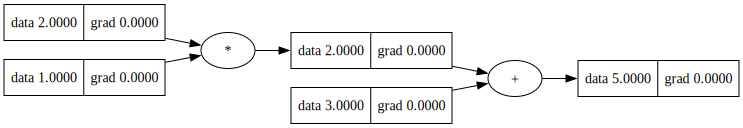

In [72]:
draw_dot(e)

In [69]:
e.backward()

In [384]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0
    
    def parameters(self):
        return []

class Neuron(Module):
    def __init__(self, nin):
        self._weights = [Value(random.uniform(-1.0, 1.0)) for _ in range(nin)]
        self._bias = Value(random.uniform(-1.0, 1.0))

    def __call__(self, inputs):
        out = sum((w*i for i, w in zip(inputs, self._weights)), self._bias)
        act = out.tanh()
        return act

    def parameters(self):
        return self._weights + [self._bias]

class Layer(Module):
    def __init__(self, nin, nout):
        self._layer = [Neuron(nin) for _ in range(nout)]

    def __call__(self, inputs):
        out = [neuron(inputs) for neuron in self._layer]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self._layer for p in n.parameters()]

class MLP(Module):
    def __init__(self, nin, nouts):
        layers = [nin] + nouts
        self._network = [Layer(layers[i], layers[i+1]) for i in range(len(layers)-1)]

    def __call__(self, inputs):
        x = inputs
        for layer in self._network:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self._network for p in layer.parameters()]

In [385]:
def dummy(x,y,w):
    return math.tanh(x + 0.5*y - 0.2*w)

In [386]:
xs = [[random.uniform(-1, 1) for _ in range(3)] for _ in range(20)]
ys = [dummy(*x) for x in xs]

In [387]:
list(zip(xs, ys))

[([0.9086582692417902, -0.050029434539520246, 0.27992603557930495],
  0.6792166443354881),
 ([0.8204486914295874, -0.679968837667037, -0.33461446422340924],
  0.4985593853438071),
 ([-0.3598565167504726, 0.1453300112273872, 0.8756918195506602],
  -0.43198121948724505),
 ([-0.7864158719821912, -0.17612312652068463, -0.3029884495611799],
  -0.6717249604798965),
 ([-0.5613529055926294, -0.5626124222659954, 0.5659137232817213],
  -0.7424163744021024),
 ([-0.7126434356553519, -0.6111003419838981, 0.8299526626957254],
  -0.8287664100735418),
 ([0.8348035331327597, 0.6369950602665635, 0.21495717452382412],
  0.8041718127295111),
 ([0.9215494760394258, 0.08159378860969246, -0.7018193233631],
  0.8014704318538257),
 ([0.37257930736300104, -0.28114130758645706, 0.09426010922576245],
  0.20998593404075036),
 ([0.5790840647613635, -0.48466349596560687, -0.5380783152920106],
  0.4172585003105248),
 ([0.06153147847937701, -0.8350296176285403, -0.8495690993845901],
  -0.18395148001068548),
 ([0.12672

In [388]:
nn = MLP(3, [8,4,4,1])
runs = []
k = 0

In [394]:
for _ in range(50):
    # forward pass
    ypred = [nn(x) for x in xs]
    
    #loss
    loss = sum([(ygt - ypr)**2 for ygt, ypr in zip(ys, ypred)])

    # backprop
    nn.zero_grad()
    loss.backward()

    # gradient update
    for p in nn.parameters():
        p.data += -0.01 * p.grad

    print(f"iter {k}: loss {loss}")
    runs.append((k, loss))
    k += 1

iter 250: loss Value(0.036946430521267934)
iter 251: loss Value(0.036866679374392704)
iter 252: loss Value(0.036787418097632155)
iter 253: loss Value(0.03670863971816773)
iter 254: loss Value(0.036630337405997346)
iter 255: loss Value(0.036552504470839395)
iter 256: loss Value(0.036475134359101366)
iter 257: loss Value(0.036398220650912874)
iter 258: loss Value(0.03632175705721944)
iter 259: loss Value(0.03624573741693827)
iter 260: loss Value(0.0361701556941732)
iter 261: loss Value(0.036095005975488974)
iter 262: loss Value(0.03602028246724218)
iter 263: loss Value(0.035945979492969585)
iter 264: loss Value(0.03587209149083085)
iter 265: loss Value(0.03579861301110607)
iter 266: loss Value(0.035725538713746056)
iter 267: loss Value(0.03565286336597527)
iter 268: loss Value(0.035580581839944996)
iter 269: loss Value(0.035508689110437586)
iter 270: loss Value(0.03543718025261896)
iter 271: loss Value(0.035366050439839605)
iter 272: loss Value(0.03529529494148265)
iter 273: loss Value(0

In [395]:
list(zip(ys, ypred))

[(0.6792166443354881, Value(0.7336768222326728)),
 (0.4985593853438071, Value(0.42621974658989487)),
 (-0.43198121948724505, Value(-0.4351606443523342)),
 (-0.6717249604798965, Value(-0.6405457906629811)),
 (-0.7424163744021024, Value(-0.7570873712941761)),
 (-0.8287664100735418, Value(-0.7906491576731072)),
 (0.8041718127295111, Value(0.7632307657725915)),
 (0.8014704318538257, Value(0.84384993185455)),
 (0.20998593404075036, Value(0.24243667120395188)),
 (0.4172585003105248, Value(0.43342515073748733)),
 (-0.18395148001068548, Value(-0.1546380142592921)),
 (-0.361717798984211, Value(-0.4660083943154763)),
 (-0.1539092863712931, Value(-0.15913407945977948)),
 (-0.759913628125265, Value(-0.7315213833805351)),
 (-0.1145124938786079, Value(-0.07574534833728351)),
 (-0.04996036909836195, Value(-0.07826648435786313)),
 (-0.17335357823280637, Value(-0.19525458773414808)),
 (-0.1859526635139674, Value(-0.18982253488287465)),
 (-0.6651031929531404, Value(-0.6150720281461638)),
 (0.71108258710

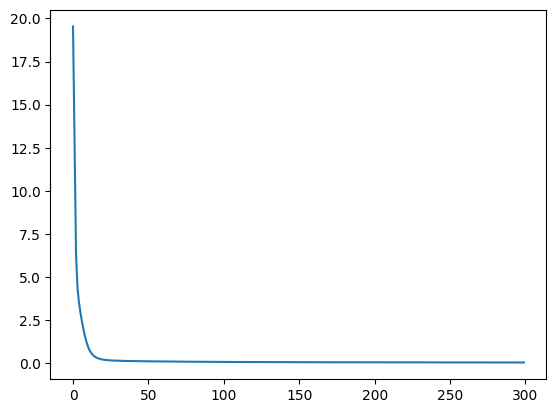

In [411]:
plt.plot([r[0] for r in runs], [r[1].data for r in runs])